<a href="https://colab.research.google.com/github/rypriyanka2005/Machine-Learning-Sem-4/blob/MLlabs/mlLab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# Load data
data = np.load("fc7_features.npz")

X = data['features']
y = data['labels']

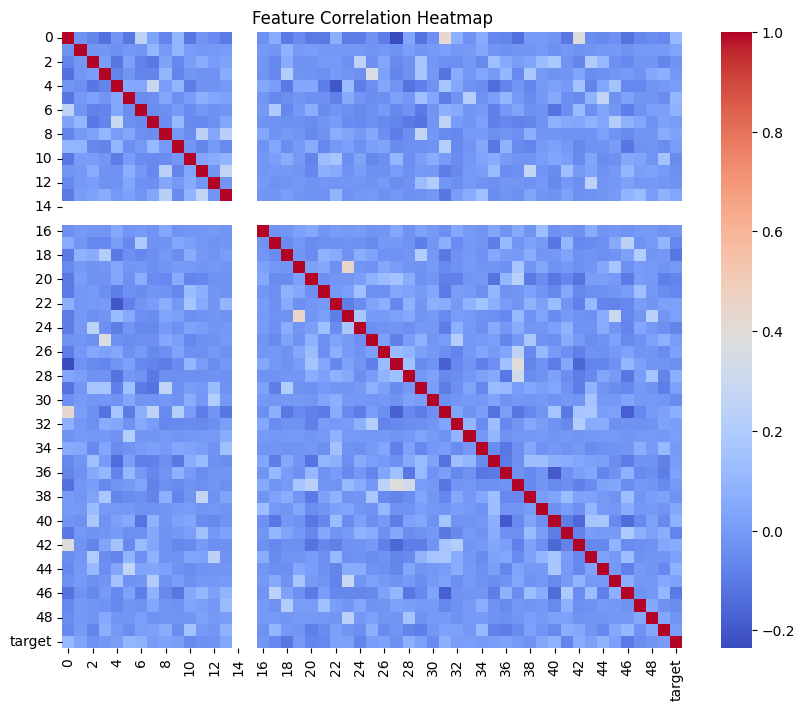

In [ ]:
# A1

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Use subset if too many features
X_subset = X[:, :50]

df = pd.DataFrame(X_subset)
df['target'] = y

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
#A2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA (99%)
pca = PCA()
pca.fit(X_train_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)
n_99 = np.argmax(cum_var >= 0.99) + 1

print("Components for 99% variance:", n_99)

pca_99 = PCA(n_components=n_99)
X_train_pca_99 = pca_99.fit_transform(X_train_scaled)
X_test_pca_99 = pca_99.transform(X_test_scaled)

# Model - Original
model_orig = LogisticRegression(max_iter=1000)
model_orig.fit(X_train_scaled, y_train)
y_pred_orig = model_orig.predict(X_test_scaled)

# Model - PCA 99%
model_pca_99 = LogisticRegression(max_iter=1000)
model_pca_99.fit(X_train_pca_99, y_train)
y_pred_pca_99 = model_pca_99.predict(X_test_pca_99)

print("Original Accuracy:", accuracy_score(y_test, y_pred_orig))
print("PCA (99%) Accuracy:", accuracy_score(y_test, y_pred_pca_99))

Components for 99% variance: 447
Original Accuracy: 0.30708661417322836
PCA (99%) Accuracy: 0.3464566929133858


In [ ]:
#A3

# PCA (95%)
n_95 = np.argmax(cum_var >= 0.95) + 1
print("Components for 95% variance:", n_95)

pca_95 = PCA(n_components=n_95)
X_train_pca_95 = pca_95.fit_transform(X_train_scaled)
X_test_pca_95 = pca_95.transform(X_test_scaled)

# Model - PCA 95%
model_pca_95 = LogisticRegression(max_iter=1000)
model_pca_95.fit(X_train_pca_95, y_train)
y_pred_pca_95 = model_pca_95.predict(X_test_pca_95)

print("PCA (95%) Accuracy:", accuracy_score(y_test, y_pred_pca_95))

Components for 95% variance: 347
PCA (95%) Accuracy: 0.2755905511811024


In [ ]:
# A4 - Sequential Feature Selection / Reduction

from sklearn.feature_selection import SelectKBest, f_classif, RFE, VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("="*50)
print("A4: Feature Reduction Results")
print("="*50)

# Remove constant features first
selector_var = VarianceThreshold(threshold=0)
X_train_clean = selector_var.fit_transform(X_train_scaled)
X_test_clean = selector_var.transform(X_test_scaled)
print(f"After removing constant features: {X_train_clean.shape[1]} features")

# Method 1: SelectKBest
kbest = SelectKBest(f_classif, k=min(100, X_train_clean.shape[1]))
X_train_kb = kbest.fit_transform(X_train_clean, y_train)
X_test_kb = kbest.transform(X_test_clean)

model_kb = LogisticRegression(max_iter=1000)
model_kb.fit(X_train_kb, y_train)
y_pred_kb = model_kb.predict(X_test_kb)
acc_kb = accuracy_score(y_test, y_pred_kb)
print(f"SelectKBest Accuracy: {acc_kb:.4f}")

# Method 2: RFE (Recursive Feature Elimination)
n_features = min(100, X_train_clean.shape[1])
rfe = RFE(RandomForestClassifier(n_estimators=50, random_state=42),
          n_features_to_select=n_features, step=20)
rfe.fit(X_train_clean, y_train)
X_train_rfe = X_train_clean[:, rfe.get_support()]
X_test_rfe = X_test_clean[:, rfe.get_support()]

model_rfe = LogisticRegression(max_iter=1000)
model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = model_rfe.predict(X_test_rfe)
acc_rfe = accuracy_score(y_test, y_pred_rfe)
print(f"RFE Accuracy: {acc_rfe:.4f}")

# COMPARISON WITH A2 AND A3
print("\n" + "="*50)
print("COMPARISON: A2 vs A3 vs A4")
print("="*50)

# Your actual results from A2 and A3
acc_original = 0.3071  # from your output
acc_pca_99 = 0.3465    # from your output (PCA 99%)
acc_pca_95 = 0.2756    # from your output (PCA 95%)

print(f"A2 - Original (no reduction):     {acc_original:.4f}")
print(f"A2 - PCA (99% variance):          {acc_pca_99:.4f}")
print(f"A3 - PCA (95% variance):          {acc_pca_95:.4f}")
print(f"A4 - SelectKBest:                 {acc_kb:.4f}")
print(f"A4 - RFE:                         {acc_rfe:.4f}")

print("\n" + "-"*50)
print("SUMMARY:")
print("-"*50)
best_acc = max(acc_original, acc_pca_99, acc_pca_95, acc_kb, acc_rfe)
best_method = ""
if best_acc == acc_original: best_method = "A2 - Original"
elif best_acc == acc_pca_99: best_method = "A2 - PCA 99%"
elif best_acc == acc_pca_95: best_method = "A3 - PCA 95%"
elif best_acc == acc_kb: best_method = "A4 - SelectKBest"
else: best_method = "A4 - RFE"

print(f"Best performing method: {best_method} with accuracy {best_acc:.4f}")

A4: Feature Reduction Results
After removing constant features: 4023 features
SelectKBest Accuracy: 0.2835
RFE Accuracy: 0.3071

COMPARISON: A2 vs A3 vs A4
A2 - Original (no reduction):     0.3071
A2 - PCA (99% variance):          0.3465
A3 - PCA (95% variance):          0.2756
A4 - SelectKBest:                 0.2835
A4 - RFE:                         0.3071

--------------------------------------------------
SUMMARY:
--------------------------------------------------
Best performing method: A2 - PCA 99% with accuracy 0.3465
